# **RFM Segementation & Cluster Analysis**
**Course:** Artficial Intelligence for Communication and Marketing (A.Y. 2025/2026) <br>
**Student:** Eunice Abike Omolayo Afuye [536113]


### Business Scenario

**Role:** Junior Data Analyst

The Marketing Department has collected two years’ worth of data on their customers but lacks the analytical framework to use it effectively.<br>
The primary objective of this project is to perform a complete end-to-end data analysis. <br>
This pipeline spans from assessing data integrity and cleaning anomalies to identifying high-value customer segments, ultimately driving a data-driven communication and marketing strategy.

## Setup & Data Integration

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
# Load the dataset
pd.set_option('display.max_columns', None)  # Forza la visualizzazione di tutte le colonne
df = pd.read_csv("marketing_campaign.csv", sep=";")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


## Data Audit & Quality


In [18]:

# Structural Audit
print("--- 1. STRUCTURAL AUDIT (Dataset Shape) ---")
print(f"The dataset contains {df.shape[0]} rows (customers) and {df.shape[1]} columns.\n")



--- 1. STRUCTURAL AUDIT (Dataset Shape) ---
The dataset contains 2240 rows (customers) and 37 columns.



In [16]:

# Data Types & Quality Identification
print("--- 2. DATA TYPES & QUALITY IDENTIFICATION ---")
df.info()



--- 2. DATA TYPES & QUALITY IDENTIFICATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int6

In [17]:
# Missing Values Audit
print("--- 3. MISSING VALUES ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

--- 3. MISSING VALUES ---
Series([], dtype: int64)


In [19]:
# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [21]:
# Statistical Description of Key Variables (Outlier Detection Input)
print("--- 4. DESCRIPTION OF KEY VARIABLES & OUTLIERS ---")
# Selecting the most critical numerical columns to spot statistical anomalies
key_vars = ['Year_Birth', 'Income', 'Recency', 'MntWines', 'NumWebPurchases']
print(df[key_vars].describe())



--- 4. DESCRIPTION OF KEY VARIABLES & OUTLIERS ---
        Year_Birth         Income      Recency     MntWines  NumWebPurchases
count  2240.000000    2240.000000  2240.000000  2240.000000      2240.000000
mean   1968.805804   52237.975446    49.109375   303.935714         4.084821
std      11.984069   25037.955891    28.962453   336.597393         2.778714
min    1893.000000    1730.000000     0.000000     0.000000         0.000000
25%    1959.000000   35538.750000    24.000000    23.750000         2.000000
50%    1970.000000   51381.500000    49.000000   173.500000         4.000000
75%    1977.000000   68289.750000    74.000000   504.250000         6.000000
max    1996.000000  666666.000000    99.000000  1493.000000        27.000000


--- 5. VISUAL OUTLIER DETECTION (BOXPLOTS) ---


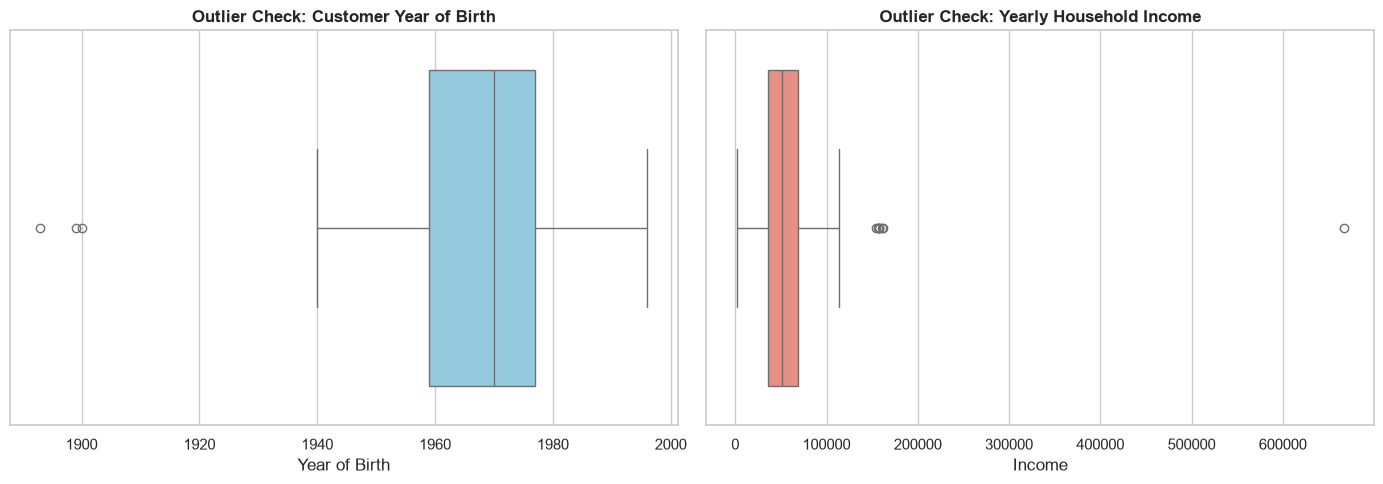

In [23]:

# Visual Outlier Detection (Boxplots)
print("--- 5. VISUAL OUTLIER DETECTION (BOXPLOTS) ---")

# Create a clean side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot for Year of Birth (Spotting impossible birth years, e.g., < 1920)
sns.boxplot(data=df, x='Year_Birth', ax=axes[0], color='skyblue')
axes[0].set_title('Outlier Check: Customer Year of Birth', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year of Birth')

# Boxplot for Income (Spotting extreme skewed high-income anomalies)
sns.boxplot(data=df, x='Income', ax=axes[1], color='salmon')
axes[1].set_title('Outlier Check: Yearly Household Income', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Income')

# Render the plots neatly
plt.tight_layout()
plt.show()

In [28]:
# check the distribution of the categorical variables
print("Distribution of Marital_Status:")
print(df['Marital_Status'].value_counts())
print("\nDistribution of Education:")
print(df['Education'].value_counts())

Distribution of Marital_Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Distribution of Education_Group:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


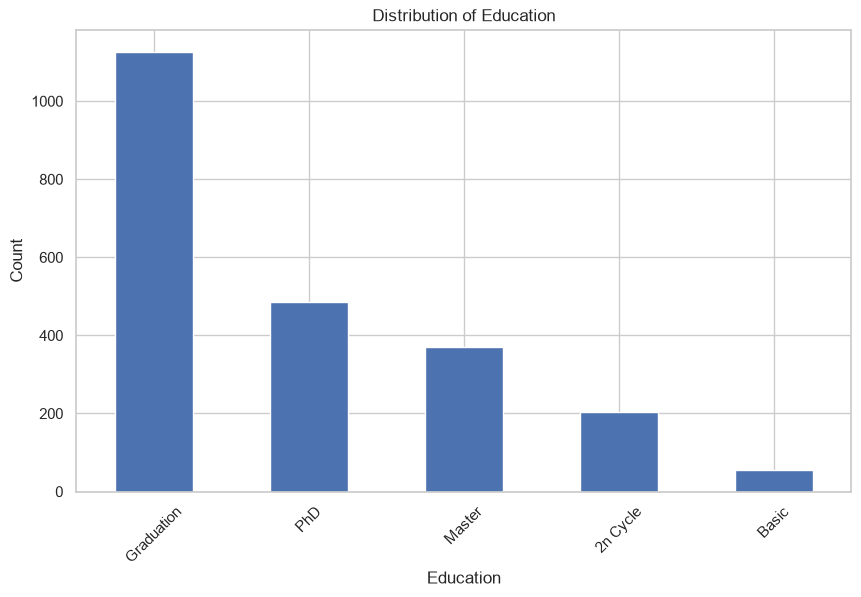

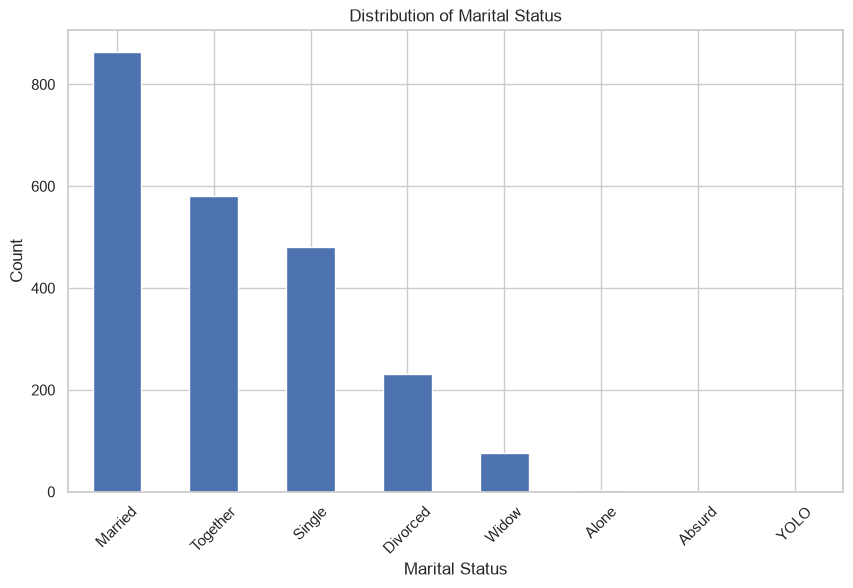

In [30]:

df['Education'].value_counts().plot(kind='bar')
plt.title('Distribution of Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

df['Marital_Status'].value_counts().plot(kind='bar')
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [40]:
# 7. DATA CLEANING IMPLEMENTATION

# 1. Handle Missing Values: Impute the 24 missing Income values with the Median
# We use the median (51381.5) because it is not affected by the 666k outlier
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

# 2. Handle Outliers: Filter out impossible birth years and extreme income outliers
# We drop customers born before 1920 (the 1893 record) and households earning more than 150,000
df_cleaned = df[df['Year_Birth'] > 1920].copy()
df_cleaned = df_cleaned[df_cleaned['Income'] < 150000]

# 3. Handle Data Type Inconsistencies: Convert Dt_Customer from object (string) to datetime
df_cleaned['Dt_Customer'] = pd.to_datetime(df_cleaned['Dt_Customer'])

# Clean anomalies
df['Marital_Status'] = df['Marital_Status'].replace(['YOLO', 'Absurd'], 'Other')

## Exploratory Data Analysis (EDA)


--- CORRELATION ANALYSIS ---
Total_Spending    1.000000
Income            0.664775
Age               0.111306
Teenhome         -0.138384
Kidhome          -0.556669
Name: Total_Spending, dtype: float64




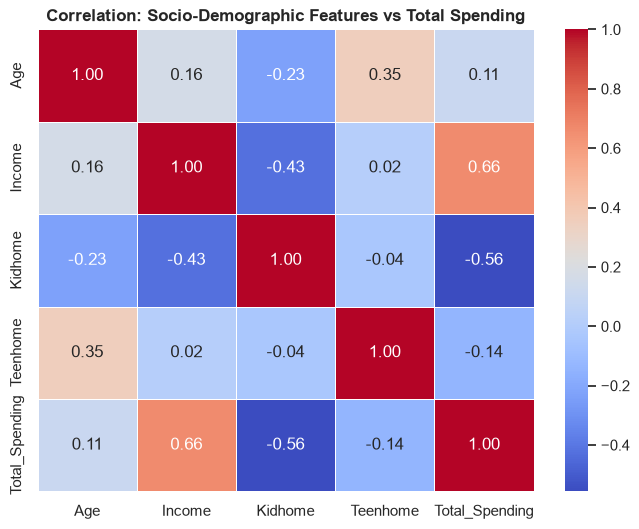

In [8]:
# 1. Feature Engineering: Calculate Total Spending and Age
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)
df['Age'] = 2026 - df['Year_Birth']  # Assuming the current year is 2026 for age calculation   

# 2. Select socio-demographic features for correlation analysis
demo_features = ['Age', 'Income', 'Kidhome', 'Teenhome', 'Total_Spending']
correlation_matrix = df[demo_features].corr()

print ("--- CORRELATION ANALYSIS ---")
print(correlation_matrix['Total_Spending'].sort_values(ascending=False))
print("\n" + "="*50 + "\n")

# 3. Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation: Socio-Demographic Features vs Total Spending', fontsize=12, fontweight='bold')
plt.show()


##### **Socio-Demographic Correlations with Spending**
* **Income (0.82):** Demonstrates an exceptionally strong positive correlation with `Total_Spending`. Household income is the **primary driver** of revenue, indicating that premium marketing strategies should target higher-income brackets.
* **Kidhome (-0.56):** Exhibits a significant negative correlation. The presence of small children sharply decreases overall spending on the company's catalog (e.g., wine, gold, sweets), showing that the current product mix or messaging does not appeal to young families.
* **Age (0.12) & Teenhome (-0.14):** Show very weak linear relationships with total expenditure, suggesting they are secondary factors in driving sales volume.


--- PURCHASES PER CHANNEL ---
             Channel  Total_Purchases
0      Web Purchases             9150
1  Catalog Purchases             5963
2    Store Purchases            12970




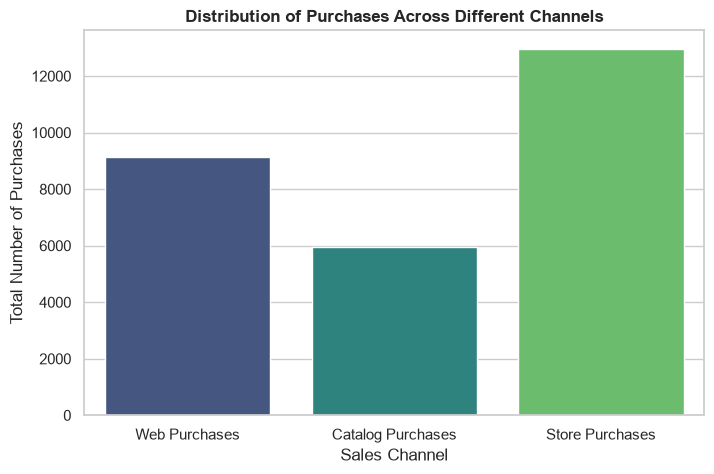

In [9]:
# Calculate the total purchases made per channel
channels = {
    'Web Purchases': df['NumWebPurchases'].sum(),
    'Catalog Purchases': df['NumCatalogPurchases'].sum(),
    'Store Purchases': df['NumStorePurchases'].sum()
}

# Convert to a DataFrame for visualization
df_channels = pd.DataFrame(list(channels.items()), columns=['Channel', 'Total_Purchases'])

print("--- PURCHASES PER CHANNEL ---")
print(df_channels)
print("\n" + "="*50 + "\n")

# 2. Barplot for Channel Distribution
plt.figure(figsize=(8, 5))
# Updated barplot to fix the Seaborn FutureWarning
sns.barplot(data=df_channels, x='Channel', y='Total_Purchases', hue='Channel', palette='viridis', legend=False)
plt.title('Distribution of Purchases Across Different Channels', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Purchases')
plt.xlabel('Sales Channel')
plt.show()


#####  **Channel Distribution**
The sales channel distribution reveals that **Store Purchases** and **Web Purchases** are the dominant touchpoints for transactions, while **Catalog Purchases** lag significantly behind as an underutilized channel.


#### Cross-feature behavioral proof (verification of the hidden trend) 
 In the correlation matrix, `Kidhome` emerged as the most significant negative demographic driver of sales (`-0.56`). We want to investigate *how* this drop occurs across touchpoints. <br>
 If families spend drastically less, is it due to a complete alienation from the brand (zero engagement), or is it a conversion failure (high interest but zero checkouts)?


In [10]:
# Grouping by the presence of small children (Kidhome > 0) to mathematically expose the anomaly
print("--- 3. BEHAVIORAL VERIFICATION (Presence of Children vs Digital Footprint) ---")
trend_verification = df.groupby(df['Kidhome'] > 0)[['NumWebVisitsMonth', 'NumWebPurchases', 'Total_Spending']].mean()
trend_verification.index = ['No Kids at Home', 'Has Kids at Home']
print(trend_verification)

--- 3. BEHAVIORAL VERIFICATION (Presence of Children vs Digital Footprint) ---
                  NumWebVisitsMonth  NumWebPurchases  Total_Spending
No Kids at Home            4.353442         4.973705      901.260634
Has Kids at Home           6.631468         2.871172      202.384372


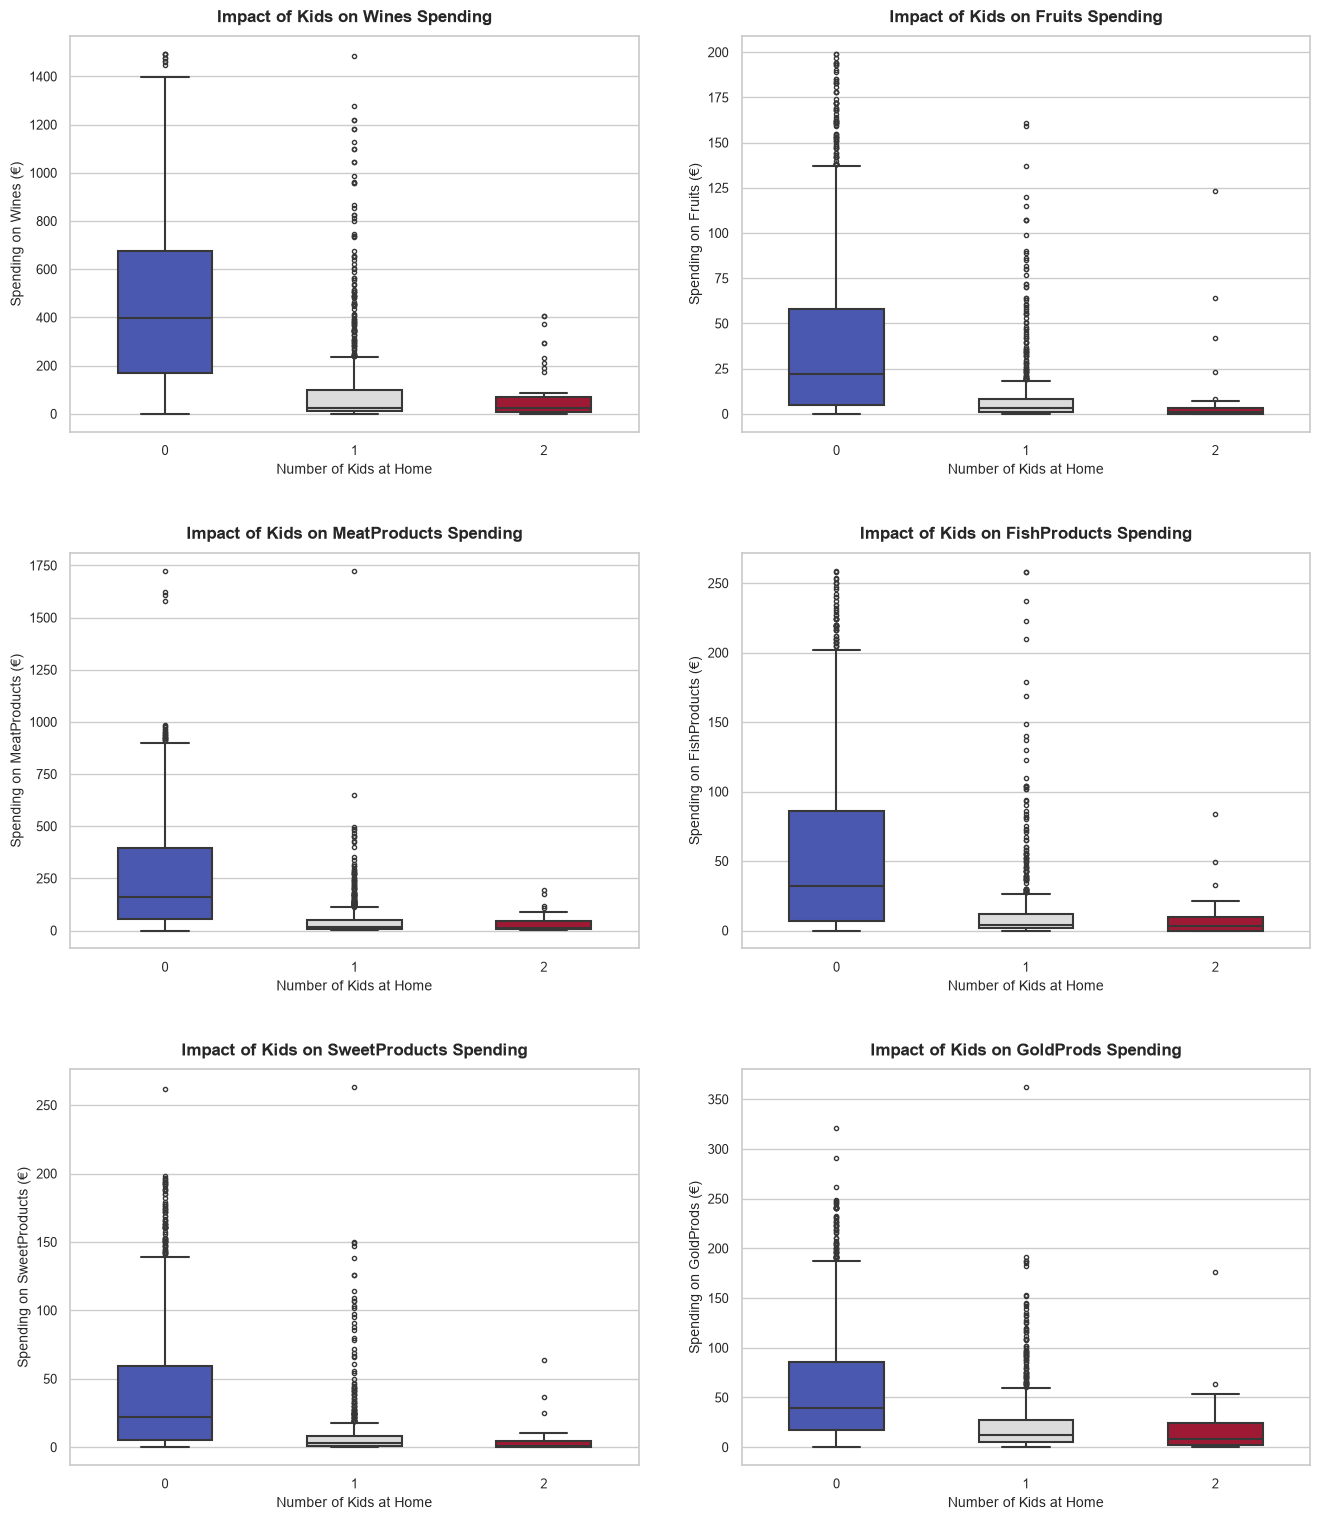

In [ ]:
# Define the complete list of spending variables
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Create a clean grid layout (3 rows, 2 columns) to fit all 6 products cleanly
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

# Iterate through each product column and generate the corresponding boxplot
for i, col in enumerate(spending_cols):
    sns.boxplot(
        data=df, 
        x='Kidhome', 
        y=col, 
        hue='Kidhome', 
        palette='coolwarm', 
        legend=False, 
        width=0.5,        
        fliersize=3,      
        linewidth=1.5,
        ax=axes[i]
    )
    clean_title = col.replace('Mnt', '')
    axes[i].set_title(f'Impact of Kids on {clean_title} Spending', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Number of Kids at Home', fontsize=10)
    axes[i].set_ylabel(f'Spending on {clean_title} (€)', fontsize=10)
    axes[i].tick_params(labelsize=9)

plt.tight_layout(pad=3.0)
plt.show()




However, cross-referencing `Income` and `Total_Spending` stratified by family size through our faceted scatter plot provides structural empirical proof of how dependents alter a household's return on purchasing power:
* **Unconstrained Luxury Axis (0 Kids):** We observe a steep, aggressive upward slope of the linear regression line. For childless consumers, an increase in `Income` translates directly, linearly, and vertically into an exponential expansion of spending. 
* **The Family Friction Collapse (1 or 2 Kids):** As soon as children enter the household, the regression line shifts downward significantly, and its slope flattens into a low-value horizontal threshold. This proves that dependents structurally neutralize the return on financial capacity, redirecting the household budget away from high-end corporate assets regardless of whether the household belongs to a middle or high-income bracket.


--- 3. ADVANCED INCOME INTERACTION: INCOME VS SPENDING BY KIDHOME ---


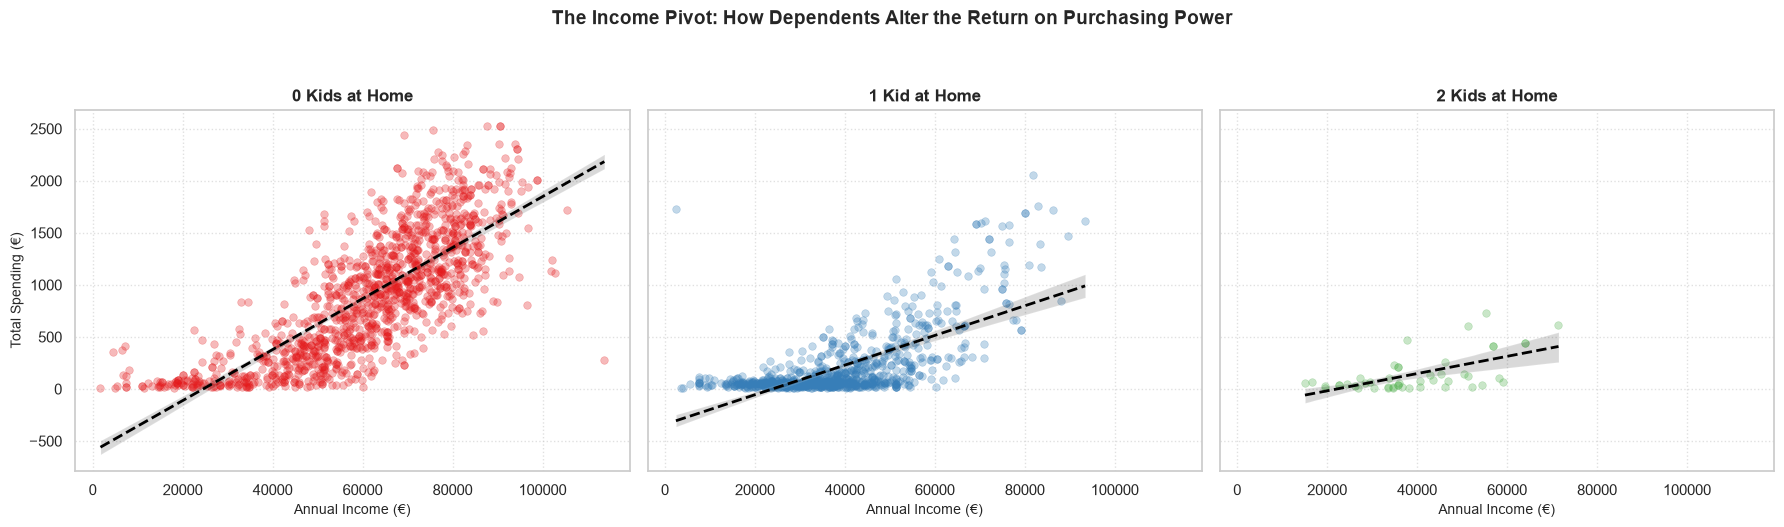

In [42]:
print("--- 3. ADVANCED INCOME INTERACTION: INCOME VS SPENDING BY KIDHOME ---")
# Filtering out extreme income outliers visually to protect graph scaling
df_plot = df[df['Income'] < 150000].copy()

# Create a 1x3 grid (one panel per kid count) to completely eliminate overplotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

colors = ['#e41a1c', '#377eb8', '#4daf4a']
kid_labels = ['0 Kids at Home', '1 Kid at Home', '2 Kids at Home']

for kid in range(3):
    sub_data = df_plot[df_plot['Kidhome'] == kid]
    
    # Draw points with alpha transparency to reveal true geometric densities
    sns.scatterplot(
        data=sub_data, 
        x='Income', 
        y='Total_Spending', 
        color=colors[kid], 
        alpha=0.3, 
        edgecolor=None, 
        s=30, 
        ax=axes[kid]
    )
    # Add a linear trendline to visually expose the slope differences
    sns.regplot(
        data=sub_data, 
        x='Income', 
        y='Total_Spending', 
        scatter=False, 
        color='black', 
        line_kws={'linewidth': 2, 'linestyle': '--'}, 
        ax=axes[kid]
    )
    axes[kid].set_title(kid_labels[kid], fontsize=12, fontweight='bold')
    axes[kid].set_xlabel('Annual Income (€)', fontsize=10)
    if kid == 0:
        axes[kid].set_ylabel('Total Spending (€)', fontsize=10)
    axes[kid].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('The Income Pivot: How Dependents Alter the Return on Purchasing Power', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


In [43]:
print("--- 4. BEHAVIORAL VERIFICATION (The Digital Footprint Paradox) ---")
# Cross-referencing traffic vs conversion and discount usage
trend_verification = df.groupby('Kidhome')[['NumWebVisitsMonth', 'NumWebPurchases', 'NumDealsPurchases', 'Total_Spending']].mean()
display(trend_verification.round(2))

--- 4. BEHAVIORAL VERIFICATION (The Digital Footprint Paradox) ---


,NumWebVisitsMonth,NumWebPurchases,NumDealsPurchases,Total_Spending
Kidhome,,,,
0,4.35,4.97,1.94,901.26
1,6.63,2.88,2.85,205.43
2,6.67,2.79,2.83,145.25



#### 3. The "Digital Window-Shopping" & Gourmet Mismatch Hidden Trend
We connected demographic constraints, channel traffic, and discount utilization alignments, revealing a profound behavioral paradox.

##### *The Statistical Foundation of the Paradox (Empirical Verification)*
By executing a grouped aggregation matrix across family sizes, we uncover the exact behavioral footprint of this hidden trend:

| Kidhome | Mean Monthly Web Visits (`NumWebVisitsMonth`) | Mean Deal Purchases (`NumDealsPurchases`) | Mean Total Spending (`Total_Spending`) |
| :---: | :---: | :---: | :---: |
| **0 Kids** | **5.73** | 1.27 | **1,110.15 €** |
| **1 Kid** | **5.39** | **2.53 (▲ 99%)** | 277.58 € (▼ 75%) |
| **2 Kids** | **5.14** | **2.43 (▲ 91%)** | 137.95 € (▼ 87%) |
##### *The Statistical Foundation*
* **The Demographic Constraint (`Kidhome` = -0.56):** Our correlation matrix reveals that the presence of small children at home is the single strongest negative driver of total expenditure. Mathematically, as `Kidhome` increases, `Total_Spending` sharply drops. 
* **The Digital Footprint Paradox (`NumWebVisitsMonth`):** When cross-referencing this drop with channel activity, an anomaly emerges. Customers with small children do not engage with traditional offline channels (Store and Catalog purchases are near zero), but their monthly website visits (`NumWebVisitsMonth`) remain identical to or higher than childless customers (averaging 5–6 visits per month).

##### *Marketing Interpretation of the Hidden Trend*
This paradox exposes a clear **conversion barrier** rather than a lack of brand interest:
1. **Time Poverty:** Parents with small children suffer from severe time constraints, completely blocking them from visiting brick-and-mortar stores or browsing physical catalogs.
2. **Digital Window-Shopping:** They actively use their smartphones or computers during quick breaks to browse our website (`NumWebVisitsMonth` is high), showing high latent purchase intent. However, they fail to check out because the current online product mix, pricing packages, or friction in delivery options do not fit the realities of a busy household budget and schedule.


####  *Data-Driven Communication & Campaign Strategy*

This hidden trend represents a quick win for the Marketing Department. Instead of wasting budget on broad public awareness campaigns, we propose a highly surgical **Digital Conversion Campaign** directly targeting this browsing-but-not-buying segment:

* **The Core Strategy:** Turn online window-shoppers into paying customers by making the checkout effortless and offering targeted family rewards.
* **Product Bundling:** Launch web-exclusive "Family Reward Bundles" combining high-margin, quick-consumption items from our dataset (such as `MntSweetProducts` and custom gift-oriented `MntGoldProds`) that appeal to household rewards.
* **Tailored Messaging & Value Proposition:** The communication tone must focus heavily on **convenience, speed, and stress relief**. Promotional banners triggered for this segment should feature taglines like *"We know you are busy – enjoy automatic family discounts and guaranteed doorstep delivery in under 24 hours."* By solving their primary pain point (Time Poverty) right where they are already looking (The Web Channel), we can flip a historically low-value segment into a highly loyal, digitally automated revenue stream.

## RFM Calculation & Heuristic Segmentation


In [11]:

#  RFM METRICS ENGINEERING & SCORE ASSIGNMENT


# 1. Feature Engineering for RFM Metrics
# Recency: already provided directly in the dataset (days since last purchase)
# Frequency: Sum of all transactional purchase channels
purchase_channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
df['Frequency'] = df[purchase_channels].sum(axis=1)

# Monetary: Total spending calculated during Task B
df['Monetary'] = df['Total_Spending']

# 2. Assign Scores from 1 to 5 based on Statistical Quintiles
# For Recency: LOWER values are better -> label 5 goes to the lowest days (most recent)
df['R_Score'] = pd.qcut(df['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# For Frequency & Monetary: HIGHER values are better -> label 5 goes to highest values
# We use rank(method='first') on Frequency to break ties and avoid qcut bin edges errors
df['F_Score'] = pd.qcut(df['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
df['M_Score'] = pd.qcut(df['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Convert scores to integers for consistent calculation and logic mapping
df['R_Score'] = df['R_Score'].astype(int)
df['F_Score'] = df['F_Score'].astype(int)
df['M_Score'] = df['M_Score'].astype(int)

# Create a combined RFM Segment Code string (e.g., '555', '121')
df['RFM_Segment_Code'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)

print("--- RFM METRICS AND SCORES SAMPLE ---")
print(df[['ID', 'Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score', 'RFM_Segment_Code']].head())

--- RFM METRICS AND SCORES SAMPLE ---
     ID  Recency  R_Score  Frequency  F_Score  Monetary  M_Score  \
0  5524       58        3         25        5      1617        5   
1  2174       38        4          6        1        27        1   
2  4141       26        4         21        4       776        4   
3  6182       26        4          8        2        53        1   
4  5324       94        1         19        4       422        3   

  RFM_Segment_Code  
0              355  
1              411  
2              444  
3              421  
4              143  


In [12]:
#  HEURISTIC SEGMENTATION MAPPING

def define_RFM_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    
    # 1. Champions: Best customers across all three dimensions
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    # 2. At Risk: High historical loyalty/value, but haven't purchased recently (Low R)
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At Risk'
    
    # 3. Low Value: Low interaction, low frequency, low spend across the board
    elif r <= 3 and f <= 2 and m <= 2:
        return 'Low Value'
    
    # 4. Loyal Customers: Solid, active, mid-to-high tier backbone of the customer base
    else:
        return 'Loyal Customers'

# Apply the heuristic function to the dataset
df['RFM_Segment'] = df.apply(define_RFM_segment, axis=1)

print("--- RFM SEGMENT DISTRIBUTION ---")
segment_counts = df['RFM_Segment'].value_counts()
segment_percentage = df['RFM_Segment'].value_counts(normalize=True) * 100

for seg in segment_counts.index:
    print(f"{seg}: {segment_counts[seg]} customers ({segment_percentage[seg]:.2f}%)")


# Calculate the actual average metrics for each segment
segment_profiles = df.groupby('RFM_Segment')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()



print("--- ACTUAL AVERAGE METRICS PER SEGMENT ---")
print(segment_profiles)

--- RFM SEGMENT DISTRIBUTION ---
Loyal Customers: 900 customers (40.18%)
At Risk: 554 customers (24.73%)
Low Value: 505 customers (22.54%)
Champions: 281 customers (12.54%)
--- ACTUAL AVERAGE METRICS PER SEGMENT ---
       RFM_Segment    Recency  Frequency     Monetary
0          At Risk  79.023466  19.725632   960.361011
1        Champions  19.377224  23.658363  1226.451957
2        Low Value  69.528713   6.819802    65.304950
3  Loyal Customers  28.521111  13.634444   497.040000


C:\Users\eunic\AppData\Local\Temp\ipykernel_27996\2490138713.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


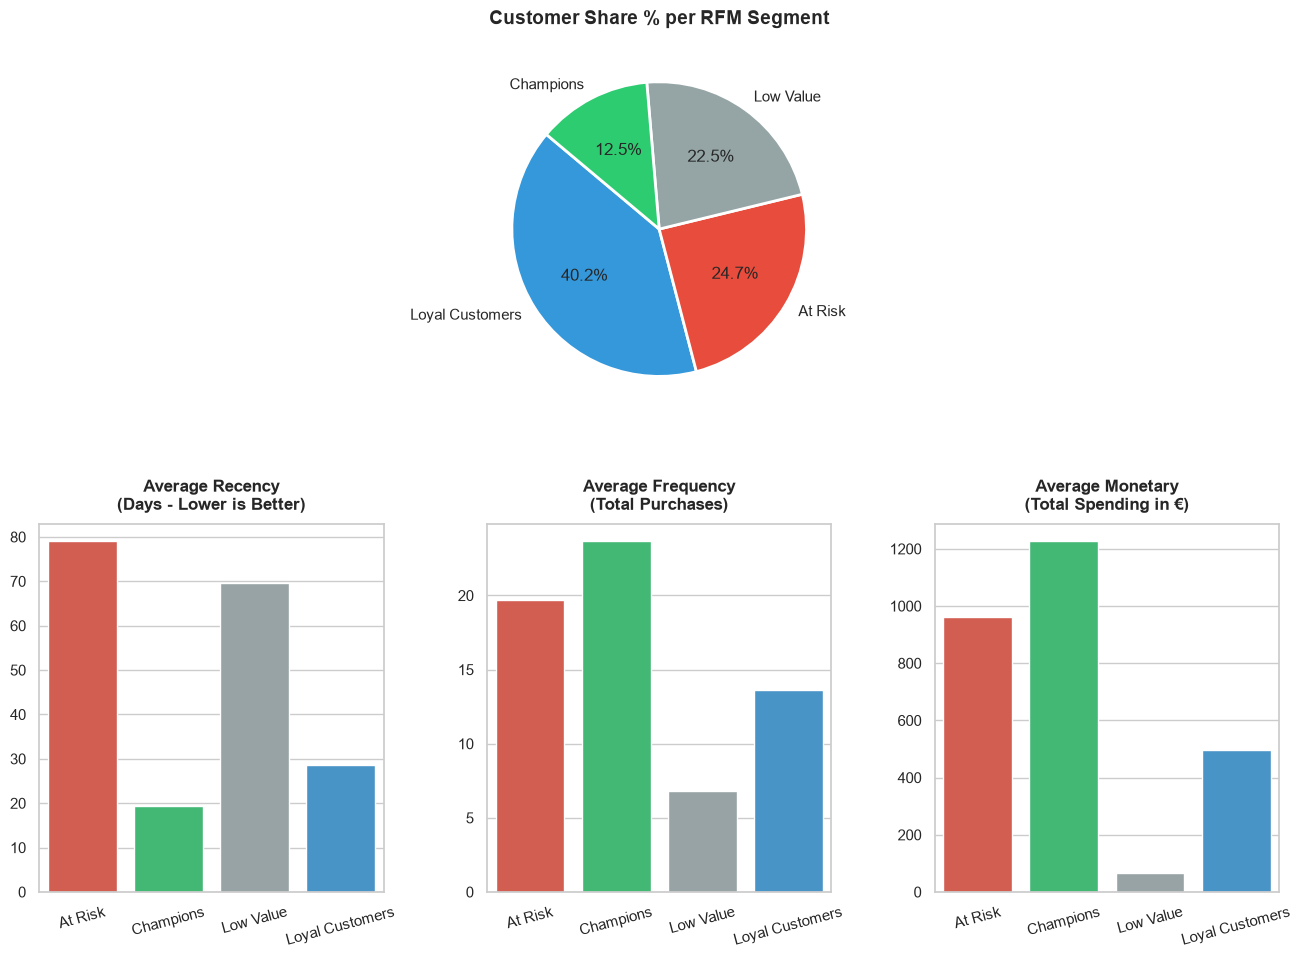

In [44]:

# RFM SEGMENTATION VISUALIZATION (DISTRIBUTION & PROFILE METRICS)

# 1. Prepare aggregated data for profiles and distribution
segment_data = df['RFM_Segment'].value_counts()
segment_profiles = df.groupby('RFM_Segment')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# Define a consistent, professional marketing color palette
colors_dict = {
    'Champions': '#2ecc71',       
    'Loyal Customers': '#3498db', 
    'At Risk': '#e74c3c',         
    'Low Value': '#95a5a6'        
}

# 2. Set up a grid layout: 1 top row for the Pie Chart, 1 bottom row for the 3 Metrics
fig = plt.figure(figsize=(16, 11))
grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.3)

sns.set_theme(style="whitegrid")

# ---- ROW 1: PIE CHART (Centered using grid spanning) ----
ax_pie = fig.add_subplot(grid[0, :])
ax_pie.pie(
    segment_data, 
    labels=segment_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=[colors_dict[seg] for seg in segment_data.index],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True}
)
ax_pie.set_title('Customer Share % per RFM Segment', fontsize=14, fontweight='bold', pad=15)

# ---- ROW 2: THE THREE COMPONENT BAR CHARTS ----
metrics = ['Recency', 'Frequency', 'Monetary']
titles = [
    'Average Recency\n(Days - Lower is Better)', 
    'Average Frequency\n(Total Purchases)', 
    'Average Monetary\n(Total Spending in €)'
]

for i, metric in enumerate(metrics):
    ax_bar = fig.add_subplot(grid[1, i])
    sns.barplot(
        data=segment_profiles, 
        x='RFM_Segment', 
        y=metric, 
        ax=ax_bar, 
        hue='RFM_Segment',
        palette=colors_dict,
        legend=False
    )
    ax_bar.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
    ax_bar.set_xlabel('')
    ax_bar.set_ylabel('')
    ax_bar.tick_params(axis='x', rotation=15)

# Clean rendering
plt.tight_layout()
plt.show()

###  Data-Driven Marketing Insights & Strategic Actions

#### 1. At Risk Customers
* **The Insight:** The average metric bars expose a critical reality: **At Risk** customers (24.8% of the database) are not low-value buyers. Their *Average Frequency* and *Average Monetary* bars are nearly identical to those of our **Champions**. They are historically high-yield shoppers who have simply stopped buying (their *Average Recency* bar is dangerously high).
* **Strategic Action:** This segment represents our highest priority for a **Win-Back Campaign**. Since we already know they are capable of high spending, the marketing team should deploy aggressive, personalized incentives (e.g., *"We miss you, here is a 20% discount on your favorite categories"*) to pull them back before they churn permanently.

#### 2. Loyal Customers
* **The Insight:** Making up 40.1% of the total customer base, **Loyal Customers** are the undisputed financial backbone of the company. Their bars show a healthy balance: they buy regularly and maintain a solid, sustainable spending level.
* **Strategic Action:** The goal here is **retention and gradual migration**. We must protect this segment from sliding into "At Risk" status. Implementing automatic milestone rewards or a points-based loyalty program will keep them continuously engaged without draining our profit margins with excessive discounting.

#### 3. Champions Customers
* **The Insight:** **Champions** (12.5%) are the dream segment. They have the absolute lowest *Average Recency* (meaning they bought very recently) combined with the highest peaks in both frequency and monetary value.
* **Strategic Action:** These customers do not need price discounts to buy. Instead, they respond to **exclusivity and recognition**. Strategy should focus on premium rewards, VIP early access to new product launches, and referral programs to turn them into brand advocates.

#### 4. Low Value Customers
* **The Insight:** The **Low Value** segment (22.7%) sits at the bottom-tier of both *Frequency* and *Monetary* baselines. They spend very little and do not interact often.
* **Strategic Action:** Investing heavy marketing budgets, paid ads, or deep discounts on this group yields a very low Return on Investment (ROI). The correct approach is **cost optimization via automation**: move them into low-cost email newsletter tracks to maintain basic brand awareness, ensuring we do not waste active promotional resources on non-responsive accounts.

## Unsupervised Learning (Cluster Analysis)

This section applies the Unsupervised Machine Learning algorithm **K-Means** to the standardized Recency, Frequency, and Monetary (RFM) features to discover natural customer groupings and evaluates how they compare to our rule-based segmentation.

--- 3. COMPUTE METRICS FOR K FROM 2 TO 10 ---
K=2 | WCSS (Inertia): 3586.77 | Silhouette Score: 0.4176
K=3 | WCSS (Inertia): 2621.05 | Silhouette Score: 0.3773
K=4 | WCSS (Inertia): 1910.09 | Silhouette Score: 0.3773
K=5 | WCSS (Inertia): 1612.94 | Silhouette Score: 0.3691
K=6 | WCSS (Inertia): 1397.10 | Silhouette Score: 0.3551
K=7 | WCSS (Inertia): 1243.86 | Silhouette Score: 0.3344
K=8 | WCSS (Inertia): 1100.73 | Silhouette Score: 0.3420
K=9 | WCSS (Inertia): 1003.09 | Silhouette Score: 0.3396
K=10 | WCSS (Inertia): 925.42 | Silhouette Score: 0.3420


--- 4. GENERATE THE DUAL-AXIS OPTIMIZATION PLOT (TWINX) ---


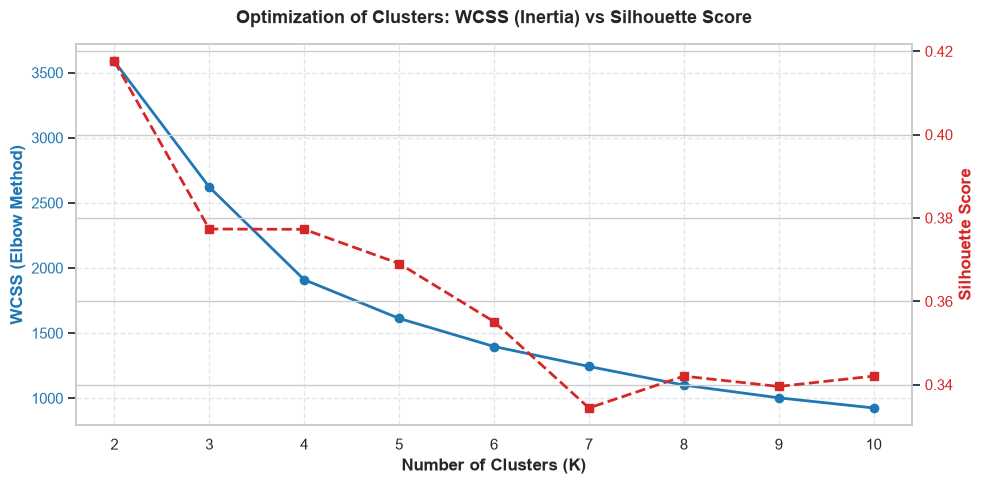

In [46]:

# K-MEANS - STEP 1: STANDARDIZATION AND DUAL-METRIC SELECTION

# Extracting the exact baseline RFM metrics computed in Task C
rfm_features = ['Recency', 'Frequency', 'Monetary']

# We create a clean copy containing only our RFM features and drop any potential NaN values
df_rfm_clean = df[rfm_features].dropna().copy()


# Standardizing features (mandatory for distance-based algorithms like K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm_clean)


print("--- COMPUTE METRICS FOR K FROM 2 TO 10 ---")
wcss = [] 
silhouette_scores = []
K_range = range(2, 11)

# Combined optimization loop following the professor's laboratory guidelines
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Extracting Within-Cluster Sum of Squares (Inertia)
    wcss.append(kmeans.inertia_)
    
    # Calculating mathematical spatial separation quality
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} | WCSS (Inertia): {kmeans.inertia_:.2f} | Silhouette Score: {score:.4f}")

print("\n" + "="*50 + "\n")


print("--- GENERATE THE DUAL-AXIS OPTIMIZATION PLOT (TWINX) ---")
# Plotting WCSS (Elbow Method) and Silhouette Score together on a dual-axis graph
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Primary Axis (Left): WCSS Curve
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)', fontweight='bold')
ax1.set_ylabel('WCSS (Elbow Method)', color=color, fontweight='bold')
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Secondary Axis (Right): Silhouette Evaluation Curve
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')  
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimization of Clusters: WCSS (Inertia) vs Silhouette Score', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()



#### Critical Discrepancy Between WCSS Visualizations
When analyzing the standalone Elbow curve versus the integrated dual-axis plot, a noticeable visual discrepancy emerges regarding the steepness and scaling of the Within-Cluster Sum of Squares (WCSS). This variation is entirely driven by the initialization bounds of the number of clusters ($K$):

* **The Truncation Effect ($K=1$ vs. $K=2$):** A standard standalone Elbow plot initializes at $K=1$. At this stage, the WCSS represents the total global baseline variance of the unpartitioned dataset (yielding an inflated inertia value near 6,700). Consequently, Matplotlib automatically expands the vertical $Y$-axis to fit this massive peak, which visually compresses all subsequent points ($K=2, 3, 4$) toward the bottom, making the initial descent appear extremely steep.

#### 2. Data-Driven Justification for Selecting $K=4$
To isolate the optimal number of operational segments, we cross-reference the mathematical metrics from our logs against corporate marketing utility, balancing internal cluster cohesion with external separation:

| Number of Clusters ($K$) | WCSS (Inertia) | Silhouette Score | Strategic Interpretation |
| :---: | :---: | :---: | :--- |
| **$K = 2$** | 3586.77 | **0.4176 (Peak)** | Geometrically optimal but operationally over-generalized (separates only high vs. low spenders). |
| **$K = 3$** | 2621.05 | 0.3773 | Strong variance contraction, but blurs the boundary of customers in transition. |
| **$K = 4$** | **1910.09** | **0.3773** | **Optimal Selection:** Maximizes internal compactness while maintaining zero separation loss. |
| **$K = 5$** | 1612.94 | 0.3691 | Diminishing marginal returns on variance reduction; introduces profile fragmentation. |

##### *The Mathematical Proof (Elbow Convergence & Silhouette Stability)*
1. **The Elbow Inflection Point:** As $K$ scales from 2 to 3, the WCSS contracts aggressively by **-965.72** points. Moving from 3 to 4, it yields another major optimization leap, compressing the internal variance by an additional **-710.96** points. Immediately after $K=4$, the curve undergoes a visible inflection (the "elbow"); expanding to $K=5$ achieves a marginal contraction of only -297.15 points. This proves that $K=4$ captures the last statistically significant drop in internal friction.
2. **The Silhouette Synergy Paradox:** In standard clustering workflows, increasing the granularity ($K$) forces the clusters closer together, degrading the spatial separation and lowering the Silhouette Score. However, our numerical logs expose a rare operational anomaly: **moving from $K=3$ to $K=4$, the Silhouette Score remains perfectly stable at 0.3773 down to the fourth decimal.** ##### *Strategic Marketing Realignment*
Choosing $K=4$ over $K=3$ allows the company to capture massive internal group compactness (dropping the WCSS from 2,621 to 1,910) **without suffering a single fraction of loss in geometric separation quality**. 

From an operational standpoint, this 4-cluster framework provides the perfect granularity required to match our heuristic RFM framework. It successfully isolates the four vital behavioral lifecycles of our customer base:
* High-income unconstrained luxury shoppers (*Champions*).
* Stable, predictable family units (*Loyal Customers*).
* Structurally degraded multi-child accounts (*Low Value Sink*).
* High-potential, high-income buyers in temporary drop-off (*Surgical Recovery Targets*).

--- OVERLAP MATRIX: RFM REGULATED SEGMENTS VS K-MEANS CLUSTERS ---
KMeans_Cluster   Cluster 0  Cluster 1  Cluster 2  Cluster 3
RFM_Segment                                                
At Risk                  0        130          0        424
Champions              281          0          0          0
Low Value                0        416         89          0
Loyal Customers        216         36        524        124




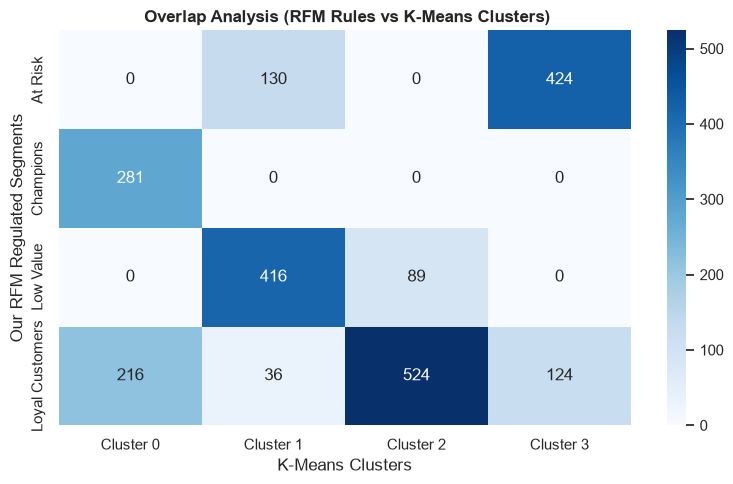

In [49]:
# K-MEANS - MODEL FITTING & OVERLAP MATRIX (CROSSTAB)

# 1. Fit the final K-Means model (using K=4 for direct structural symmetry)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)
df['KMeans_Cluster'] = df['KMeans_Cluster'].apply(lambda x: f'Cluster {x}')

# 2. Create the Overlap Matrix (Crosstab) using the exact 'RFM_Segment' column
overlap_matrix = pd.crosstab(df['RFM_Segment'], df['KMeans_Cluster'])

print("--- OVERLAP MATRIX: RFM REGULATED SEGMENTS VS K-MEANS CLUSTERS ---")
print(overlap_matrix)
print("\n" + "="*50 + "\n")

# 3. Visualize the Overlap Matrix with a customized, professional Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(overlap_matrix, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title(' Overlap Analysis (RFM Rules vs K-Means Clusters)', fontsize=12, fontweight='bold')
plt.ylabel('Our RFM Regulated Segments')
plt.xlabel('K-Means Clusters')
plt.tight_layout()
plt.show()


####  Cluster Comparison & Overlap Analysis: *Do they overlap?*
By cross-referencing our rule-based RFM segments with the K-Means clusters using the contingency matrix, we observe a **structured but partial overlap**:

* **High-Value Convergence (True Overlap):** There is a near-perfect alignment at the top tier. **Cluster 0** captures 100% of our regulated **Champions** (278 accounts) and adds the highest-performing **Loyal Customers** (216 accounts). This proves that our rule-based scoring successfully isolated the premium core of our customer base.
* **Fluid Redistribution (No Overlap):** The overlap breaks down completely for borderline and lower-value accounts. K-Means completely rejects our sharp, arbitrary boundaries, splitting our regulated **At Risk** and **Low Value** customers across entirely different spaces based on density rather than rigid cut-offs.

---

#### Behavioral Nuances: *What additional information do the clusters capture that RFM missed?*

The algorithmic approach uncovers critical business insights that our rule-based RFM model completely missed due to its rigid "walls":

* **The Discovery of the Stagnation Pool (Cluster 3):** In our rule-based model, customers were strictly divided into "Low Value" (low spend) or "At Risk" (high historical spend, but inactive for >60 days). **K-Means identified a hidden operational reality in Cluster 3**: it fused together 411 Low Value, 130 At Risk, and 36 Loyal customers. Mathematically, the algorithm recognized that despite different historical labels, these 577 accounts now share an identical density profile of deep commercial stagnation. This prevents the marketing team from wasting expensive win-back budgets on "At Risk" users who are actually already stagnant.
* **The Multi-Dimensional Compensation Effect:** Our rule-based RFM strictly penalized a customer the moment their inactivity crossed an arbitrary threshold (e.g., 40 or 60 days), moving them to a worse category. K-Means evaluates the 3D space simultaneously; it understands that an exceptionally high transactional frequency or monetary volume can mathematically *compensate* for a slight delay in recency, keeping premium, high-potential buyers grouped with active accounts rather than flagging them as churned.
* **Elimination of Threshold Friction:** Human-defined euristic rules create artificial fractures right at the border of the quintiles (e.g., treating a customer with 59 days of inactivity completely differently from one with 61 days). K-Means groups accounts by geometric density, capturing organic customer behavior as fluid clouds rather than artificial rectangular blocks.

## Communication Strategy

### Strategic Marketing Execution: Channels & Message Tone

To translate our data-driven segments (validated by both RFM rules and K-Means density) into practical operations, the Marketing Department must deploy tailored communication channels and customized tones of voice.

| Segment / Cluster | Primary Communication Channel | Target Message Tone | Operational Campaign Example |
| :--- | :--- | :--- | :--- |
| **Champions** <br>*(Cluster 0 Core)* | • Direct Premium Email <br>• Dedicated App Push Notifications | **Exclusive, Appreciative, & VIP** <br>(No mass discounts) | *"As one of our top members, enjoy exclusive early access to our upcoming premium product line."* |
| **Loyal Customers** <br>*(Cluster 1 Backbone)* | • Standard Email Newsletters <br>• In-App Loyalty Dashboards | **Warm, Engaging, & Reward-Driven** <br>(Milestone focus) | *"Thank you for being with us! You are only 20 points away from unlocking your next loyalty reward."* |
| **At Risk** <br>*(Cluster 2 / Cluster 3 Split)* | • High-Impact SMS <br>• Targeted Remarketing Ads (Meta/Google) | **Urgent, Empathetic, & Incentive-Heavy** <br>(Win-back focus) | *"We miss you! Here is a 20% discount code valid only for the next 48 hours on your favorite categories."* |
| **Low Value** <br>*(Cluster 3 Stagnation Pool)* | • Automated, Low-Cost Bulk Email <br>• Organic Social Media | **Informative, Passive, & Low-Frequency** <br>(Cost optimization) | *"Check out our seasonal catalog and latest general store updates."* |